# Portfolio Replica — EDA & Preprocessing

## Problem

We aim to **replicate a black-box portfolio** (e.g. `HFRXGL`) using only its **observed return series**. The underlying holdings are unknown.

**Possible Approach:** construct a portfolio of **liquid Futures contracts** whose returns track the target via **sparse, regularised regression (Lasso / ElasticNet)** in a rolling framework.

---

## Data Overview

- **Source:** Bloomberg
- **Frequency:** Weekly (end-of-week)
- **Period:** Oct 2007 – Apr 2021 (~700 weeks)
- **Currency:** Local (multi-currency)

### Targets
`HFRXGL`, `MXWO`, `MXWD`, `LEGATRUU`

### Futures Universe

- **Equities:** `ES1`, `NQ1`, `VG1`, `TP1`, `LLL1`
- **Bonds:** `TY1`, `TU2`, `RX1`, `DU1`
- **Commodities:** `GC1`, `CO1`

---

## Objective of This Notebook

Prepare clean, reliable inputs for the replication model:

---

## Workflow
0. Imports & Setup
1. Data Loading & Black Litterman
2. Data Quality Checks
3. Data Exploration
4. Fama-French 3-Factor Analysis
5. Summary


---
### 0. Imports & Setup


In [17]:
from plots import *
from utilities import *
import numpy as np
import pandas as pd
import statsmodels.api as sm
import urllib.request
import zipfile
import io
import ssl
import traceback

import warnings
warnings.filterwarnings("ignore", message="Values in x were outside bounds")


# ── Configuration ──────────────────────────────────────────────────────────
DATA_PATH      = "Dataset3_PortfolioReplicaStrategy.xlsx"
ANNUAL_FACTOR  = 52

TARGETS        = ["HFRXGL", "MXWO", "MXWD", "LEGATRUU"]
MAIN_TARGET    = "HFRXGL"

FUTURES        = ["RX1", "TY1", "GC1", "CO1", "ES1",
                  "VG1", "NQ1", "LLL1", "TP1", "DU1", "TU2"]

# Visualization
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)

---
## 1. Data Loading & Optimal Portfolio Construction Methodology

To build our synthetic market index (which we will refer to as the **"Monster Index"**), we utilize three different approaches based on portfolio optimization. Each model serves a distinct analytical purpose:

### 1. Unconstrained Markowitz Model (MVO)
*Modern Portfolio Theory (MVO)* attempts to find the combination of assets that maximizes expected return for a given level of risk, or minimizes volatility for a given return target.
*We do not impose any bounds**. The model is entirely free to assign negative weights (short-selling) or weights exceeding 100% (leverage).

### 2. Constrained Markowitz Model (Long-Only MVO)
This uses the same mathematical engine as the previous model, but introduces constraints to reflect realistic investing behavior. We impose strict limits (**Bounds: 0.01% - 100%**). This means we prohibit short-selling (no negative weights allowed) and prevent the use of leverage, while also forcing the sum of all weights to be exactly 100%.


### 3. Black-Litterman Model
The Black-Litterman model was designed to overcome the main flaw of Markowitz optimization: its extreme sensitivity to historical input data. Instead of using historical returns to find optimal weights, **it reverse-engineers the process**. It starts from the actual market capitalizations (the *Benchmark Proportions*) to deduce the market-implied expected returns. At this point, the investor is allowed to inject their personal forecasts (*Views*).



=== Model 1: Unconstrained Markowitz ===
          Weight
MXWO      2.5915
MXWD     -2.4580
LEGATRUU  0.9880
HFRXGL   -0.1215

=== Model 2: Constrained Markowitz (0.01% Min) ===
          Weight
MXWO      0.1009
MXWD      0.0001
LEGATRUU  0.8989
HFRXGL    0.0001

=== Model 3: Black-Litterman ===
          Weight
MXWO      0.4785
MXWD      0.3774
LEGATRUU  0.0459
HFRXGL    0.0982



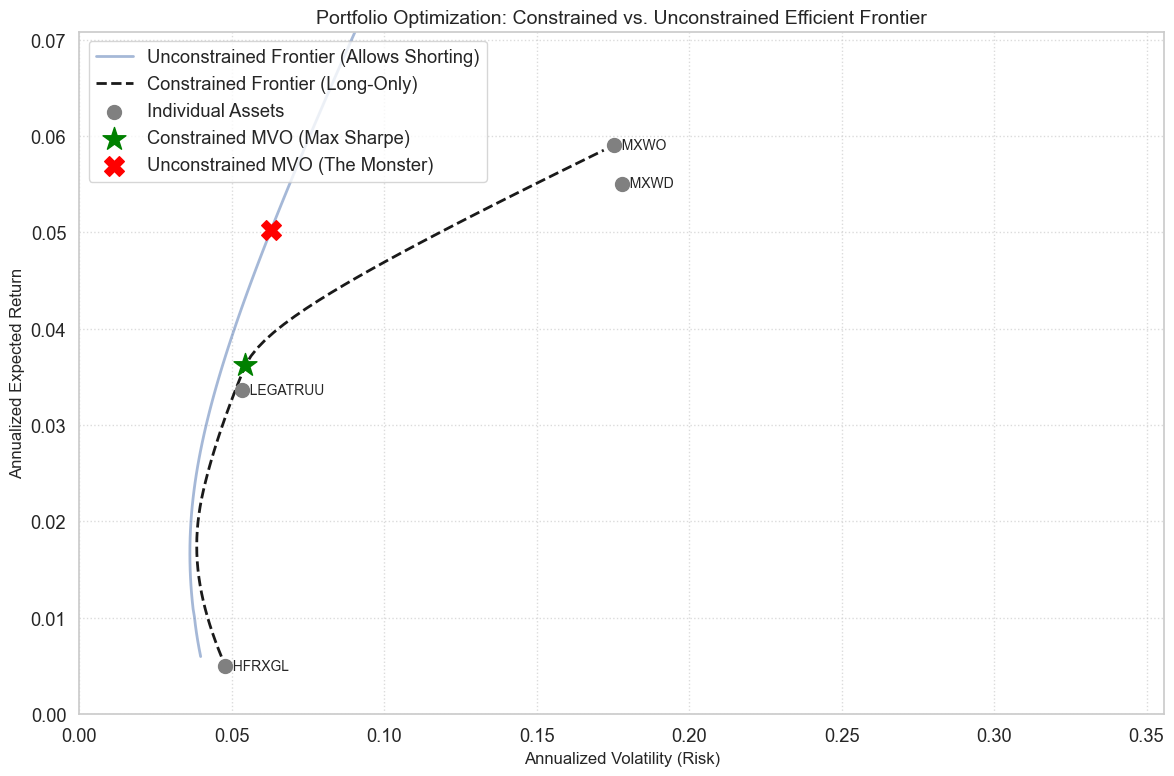

In [18]:
# DATA LOADING & PREPROCESSING
data = pd.read_excel(DATA_PATH, header=0)

# Rename first column to Date and set index
data.rename(columns={data.columns[0]: 'Date'}, inplace=True)
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Strip hidden spaces & Clean data to numeric
data.columns = [str(c).strip() for c in data.columns]
data = data.apply(pd.to_numeric, errors='coerce').dropna(how='all')

# Calculate Returns
all_returns = data.pct_change().dropna()

# Isolate the 4 targets & compute Covariance
tickers = ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL']
ret_data = all_returns[tickers].dropna()
cov_mat = ret_data.cov()
hist_exp_ret = ret_data.mean() * 52


# MODEL 1: UNCONSTRAINED MARKOWITZ
mvo_weights_unconstrained = get_unconstrained_markowitz_weights(all_returns, tickers)

print("=== Model 1: Unconstrained Markowitz ===")
print(mvo_weights_unconstrained.round(4).to_frame("Weight"))
print()


# MODEL 2: CONSTRAINED MARKOWITZ (Bounds: 0.01% to 100%)
mvo_weights_constrained = get_constrained_markowitz_weights(all_returns, tickers)

print("=== Model 2: Constrained Markowitz (0.01% Min) ===")
print(mvo_weights_constrained.round(4).to_frame("Weight"))
print()


# MODEL 3: BLACK-LITTERMAN (Market Implied + Views)
bench_prop_dict = {'MXWO': 0.4785, 'MXWD': 0.3774, 'LEGATRUU': 0.0459, 'HFRXGL': 0.0982}
bl_weights = get_black_litterman_weights(all_returns, tickers, bench_prop_dict)

print("=== Model 3: Black-Litterman ===")
print(bl_weights.round(4).to_frame("Weight"))
print()


# Create Portfolio for EDA
all_returns['MVO_Unconstrained_Index'] = ret_data.dot(mvo_weights_unconstrained)
all_returns['MVO_Constrained_Index'] = ret_data.dot(mvo_weights_constrained)
all_returns['BL_Index'] = ret_data.dot(bl_weights)

# Load Metadata
meta = pd.read_excel(DATA_PATH, header=None, skiprows=3, nrows=3)
names_list = meta.iloc[0, 1:].tolist()
tickers_list = [str(t).strip() for t in meta.iloc[2, 1:].tolist()]
variable_info = dict(zip(tickers_list, names_list))

# Append custom indices to metadata dictionary for future plotting
variable_info['MVO_Unconstrained_Index'] = "Unconstrained MVO Monster Index"
variable_info['MVO_Constrained_Index'] = "Constrained MVO Index (Long-Only)"
variable_info['BL_Index'] = "Black-Litterman Market Index"

# Plot
plot_efficient_frontiers(
    cov_mat=cov_mat, 
    hist_exp_ret=hist_exp_ret, 
    tickers=tickers, 
    mvo_weights_constrained=mvo_weights_constrained, 
    mvo_weights_unconstrained=mvo_weights_unconstrained
)


### Analysis of the Optimization Results

By observing the weights generated by the three different models, we can clearly see their distinct behaviors:

*   **Model 1: Unconstrained Markowitz**
    The unconstrained solver exploits the high historical correlation between `MXWO` (World) and `MXWD` (All Country World) by taking extreme, highly leveraged positions: a massive **+259% long** position in `MXWO` offset by a **-246% short** position in `MXWD`. It also heavily leverages bonds (`LEGATRUU` at ~99%) while slightly shorting the hedge fund index. While mathematically "optimal" on past data, this portfolio is practically untradable and highly unstable.

*   **Model 2: Constrained Markowitz (Long-Only)**
    Once leverage and short-selling are disabled (weights bounded between 0.01% and 100%), the optimizer aggressively allocates capital to the asset with the historically best risk-adjusted return (Sharpe Ratio). The result is a highly defensive portfolio dominated by Global Bonds (**`LEGATRUU` at ~90%**), with a marginal allocation to `MXWO` (~10%). The remaining assets (`MXWD` and `HFRXGL`) are completely ignored and crushed to the minimum bound of 0.01%.

*   **Model 3: Black-Litterman (Market Implied)**
    As expected, without injecting any subjective investor views (*Delta = 0*), the Black-Litterman model gracefully defaults to the provided benchmark proportions, that we set at the begin. So without views is no sense use Black Litterman

---
See the result we add to the targets:
 - `MVO_Unconstrained_Index` (like our Monster Index)
 - `MVO_Constrained_Index`


In [19]:
 nuovi_target = ['MVO_Unconstrained_Index', 'MVO_Constrained_Index']
for t in nuovi_target:
    if t not in TARGETS:
        TARGETS.append(t)
 print(TARGETS)

['HFRXGL', 'MXWO', 'MXWD', 'LEGATRUU', 'MVO_Unconstrained_Index', 'MVO_Constrained_Index']


---
## 2 · Data Quality Checks

Before any analysis we need to understand the data's health:

1. **Missing values** — Bloomberg data can have gaps when a market was closed or a series had a delayed start.
2. **Data types** — confirm everything is numeric.
3. **Descriptive statistics** — catch obvious anomalies (negative prices, extreme outliers, zero-variance columns).

In [20]:
# ── 2.1 Data Health Summary ───────────────────────────────────────────────
# Consolidate health checks into one view
health = pd.DataFrame({
    "Dtype": data.dtypes,
    "Missing": data.isnull().sum(),
    "Missing (%)": (data.isnull().sum() / len(data) * 100).round(2)
}).sort_values("Missing", ascending=False)

print("=== Data Health Summary (Issues Only) ===")
# Show only columns that actually have missing values
missing_only = health[health["Missing"] > 0]
if missing_only.empty:
    print("All series are 100% complete. No missing values found.")
else:
    display(missing_only)

# ── 2.2 Descriptive Stats (Levels) ────────────────────────────────────────
# Transposed to accommodate your TARGETS + FUTURES universe (15 columns)
print("\n=== Descriptive Statistics (Price Levels) ===")
display(data.describe().round(2).T)

=== Data Health Summary (Issues Only) ===
All series are 100% complete. No missing values found.

=== Descriptive Statistics (Price Levels) ===


,count,mean,std,min,25%,50%,75%,max
MXWO,705.0,1644.13,443.39,705.35,1293.43,1646.69,1978.83,2944.05
MXWD,705.0,404.15,100.98,176.10,328.79,402.57,478.41,702.99
LEGATRUU,705.0,452.20,47.34,342.25,431.74,456.73,478.19,559.31
HFRXGL,705.0,1210.09,73.97,1021.40,1158.15,1215.20,1254.25,1415.11
RX1,705.0,147.28,19.32,110.20,128.90,148.00,163.24,179.32
TY1,705.0,125.97,6.30,110.52,121.20,126.00,130.34,140.33
GC1,705.0,1317.90,274.48,732.70,1178.00,1283.00,1499.70,2001.20
CO1,705.0,77.02,26.79,19.33,54.27,72.05,105.78,140.67
ES1,705.0,1960.44,770.07,689.50,1314.50,1909.25,2569.75,4132.80
VG1,705.0,3072.17,473.81,1873.00,2753.00,3071.00,3433.00,4476.00


---
## 3. Data Exploration

Let's analyze the potential replication targets to understand their characteristics.



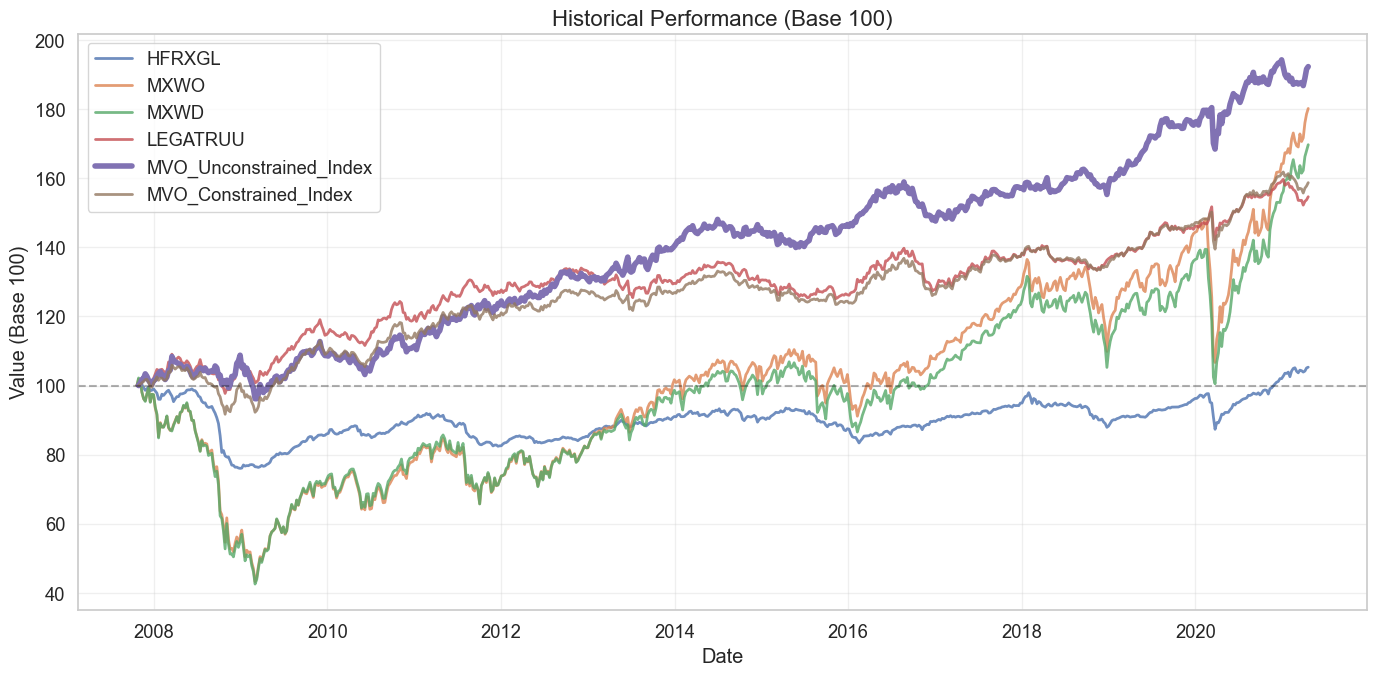

In [21]:
# ── 3. Target Exploration ──────────────────────────────────────────────────

original_targets = [t for t in TARGETS if t in data.columns]
plot_df = data[original_targets].copy()

# Convert New Index returns back to a price series starting at 1
synthetic_targets = [t for t in TARGETS if t not in data.columns]
for t in synthetic_targets:
    plot_df[t] = (1 + all_returns[t]).cumprod()

plot_normalized_series(plot_df, TARGETS, base=100, highlight_col='MVO_Unconstrained_Index')


### Correlation & probability distribution analysis
Understanding the shape and the relationships between different indices helps us understanding the behavior of our ingredients and identify potential replication components.

=== Target Correlation ===


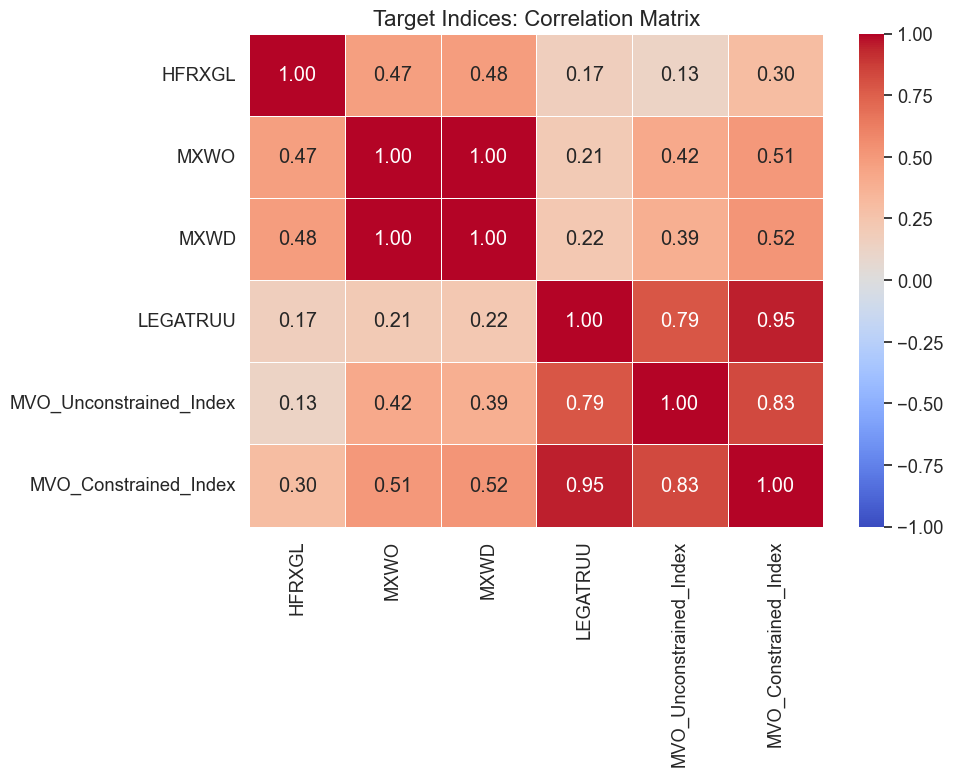


=== Return Distributions ===


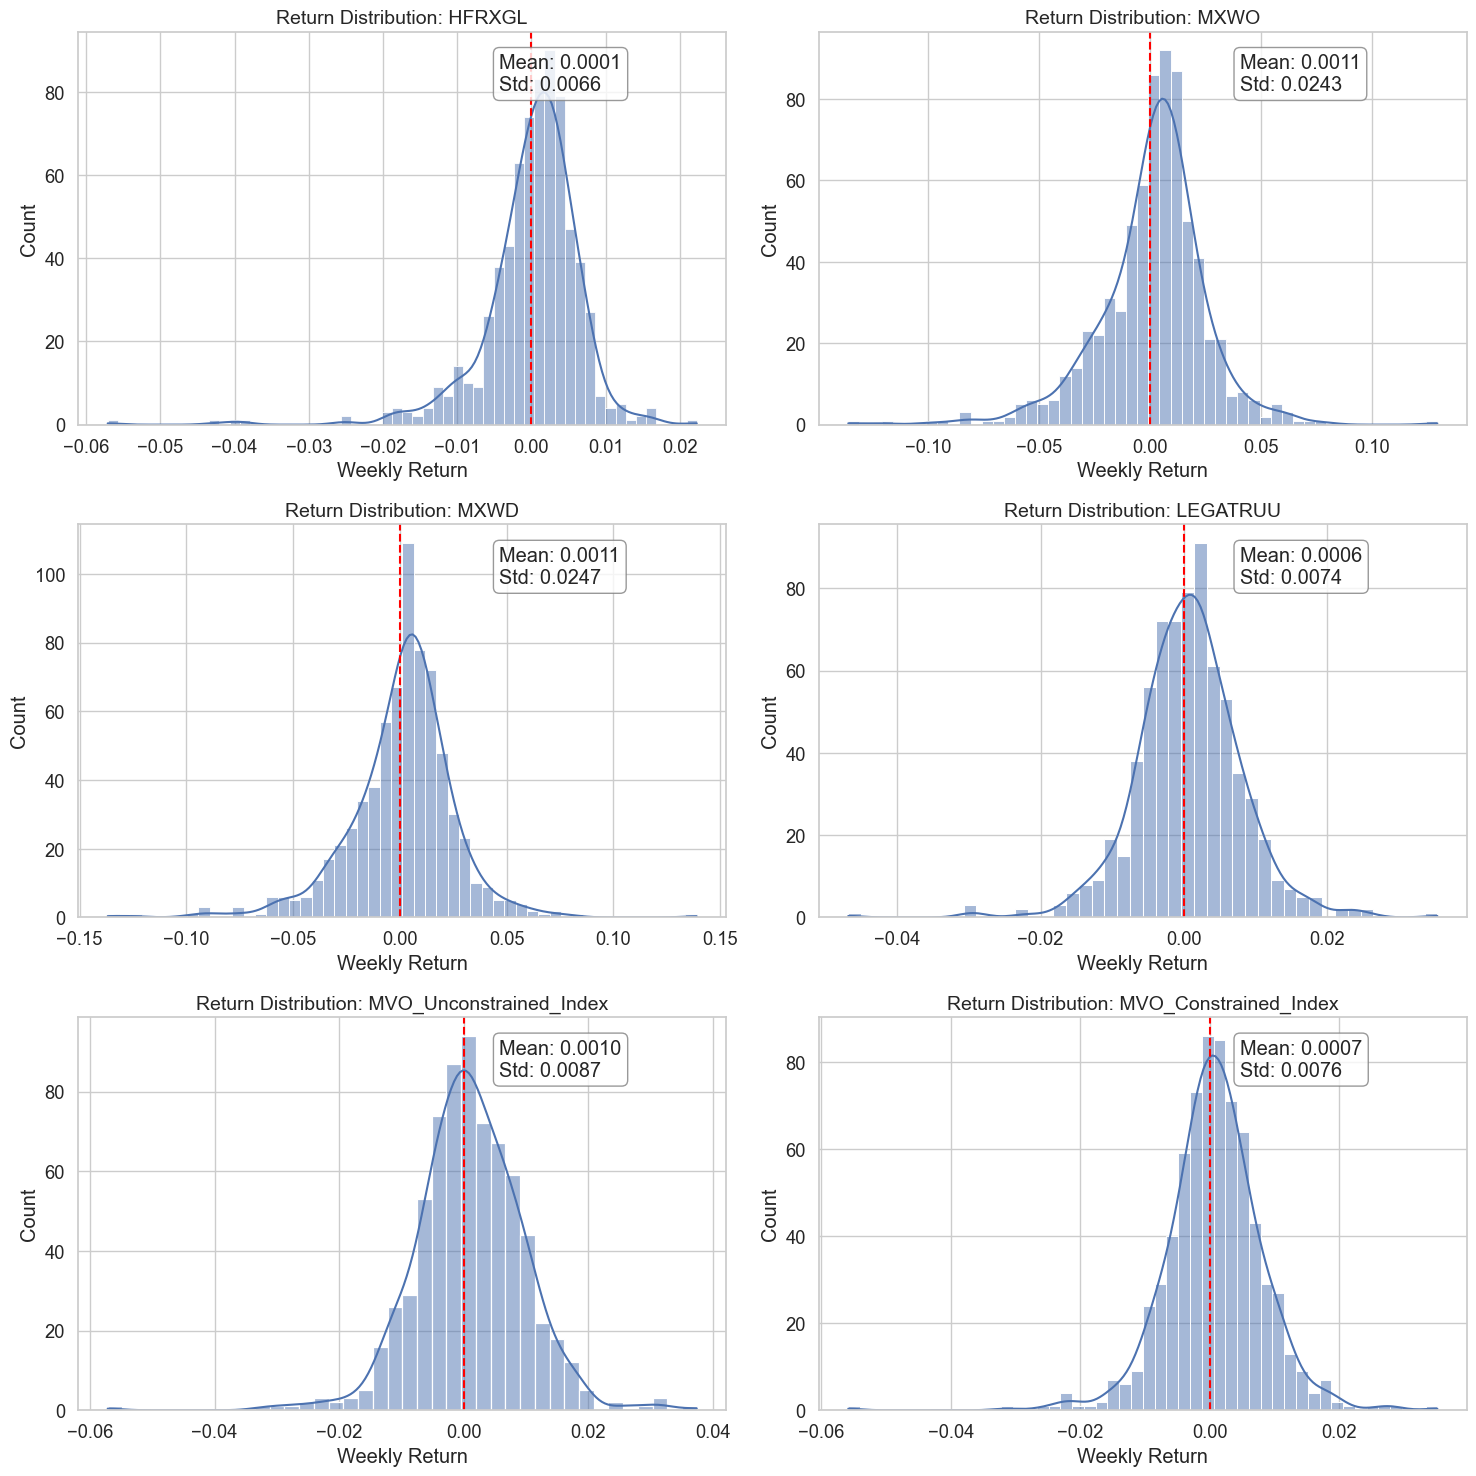


=== Rolling Correlation (vs HFRXGL) ===


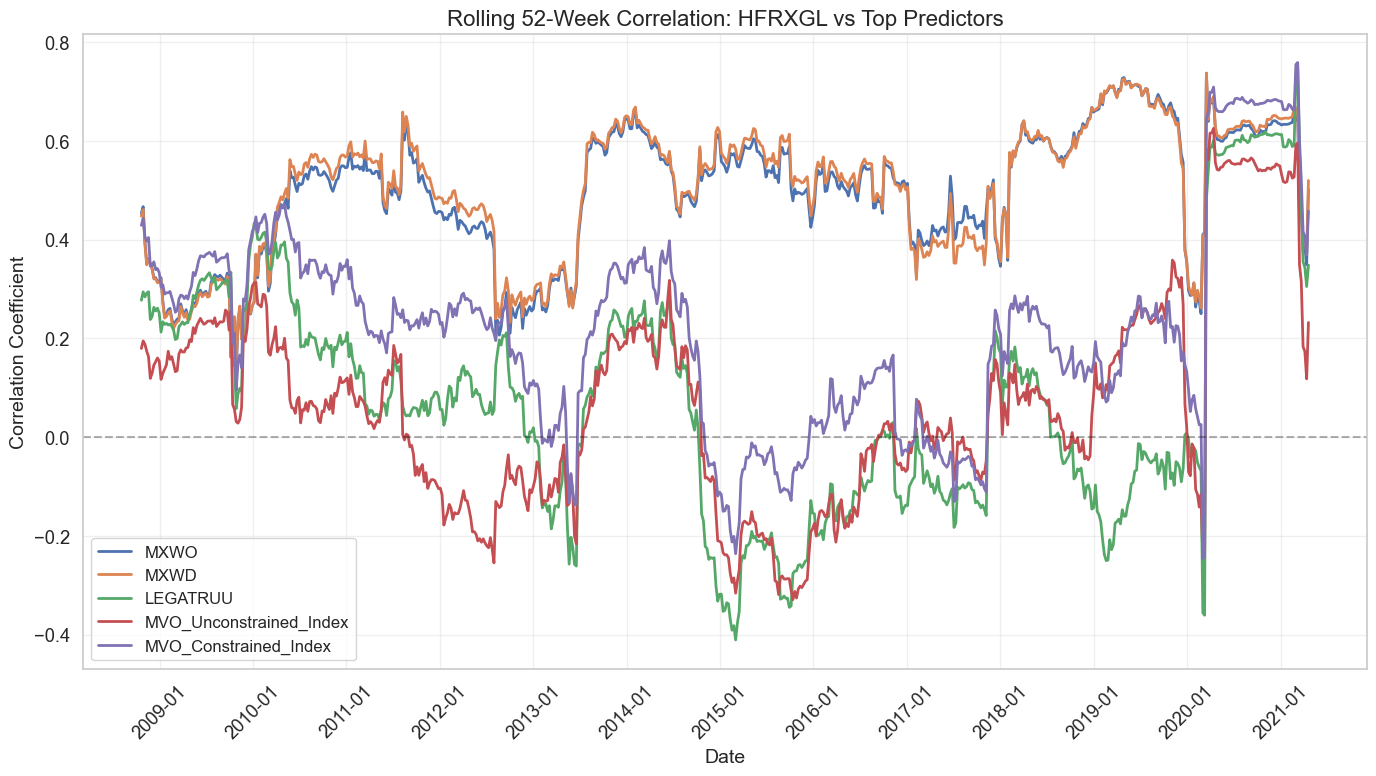

In [22]:
# ── 4. Target EDA (Exploratory Data Analysis) ──────────────────────────────
returns_targets = all_returns[TARGETS]
# 1. Static Correlation
print("=== Target Correlation ===")
plot_correlation_heatmap(returns_targets, title='Target Indices: Correlation Matrix')

# 2. Return Distributions
print("\n=== Return Distributions ===")
plot_return_distributions(returns_targets, TARGETS)


# 3. Rolling Correlation (Instability Check)
print(f"\n=== Rolling Correlation (vs {MAIN_TARGET}) ===")
compare_list = [t for t in TARGETS if t != MAIN_TARGET]

# This works perfectly for comparing indices too!
plot_rolling_correlations(returns_targets, MAIN_TARGET, compare_list, window=52)


<br>

Let's examine the statistical properties of our target indices.


=== Top Futures Correlated with HFRXGL ===


,Correlation_with_Target
ES1,0.441119
TP1,0.394622
NQ1,0.390603
VG1,0.341651
CO1,0.277859



=== Normality Check (QQ Plots) ===


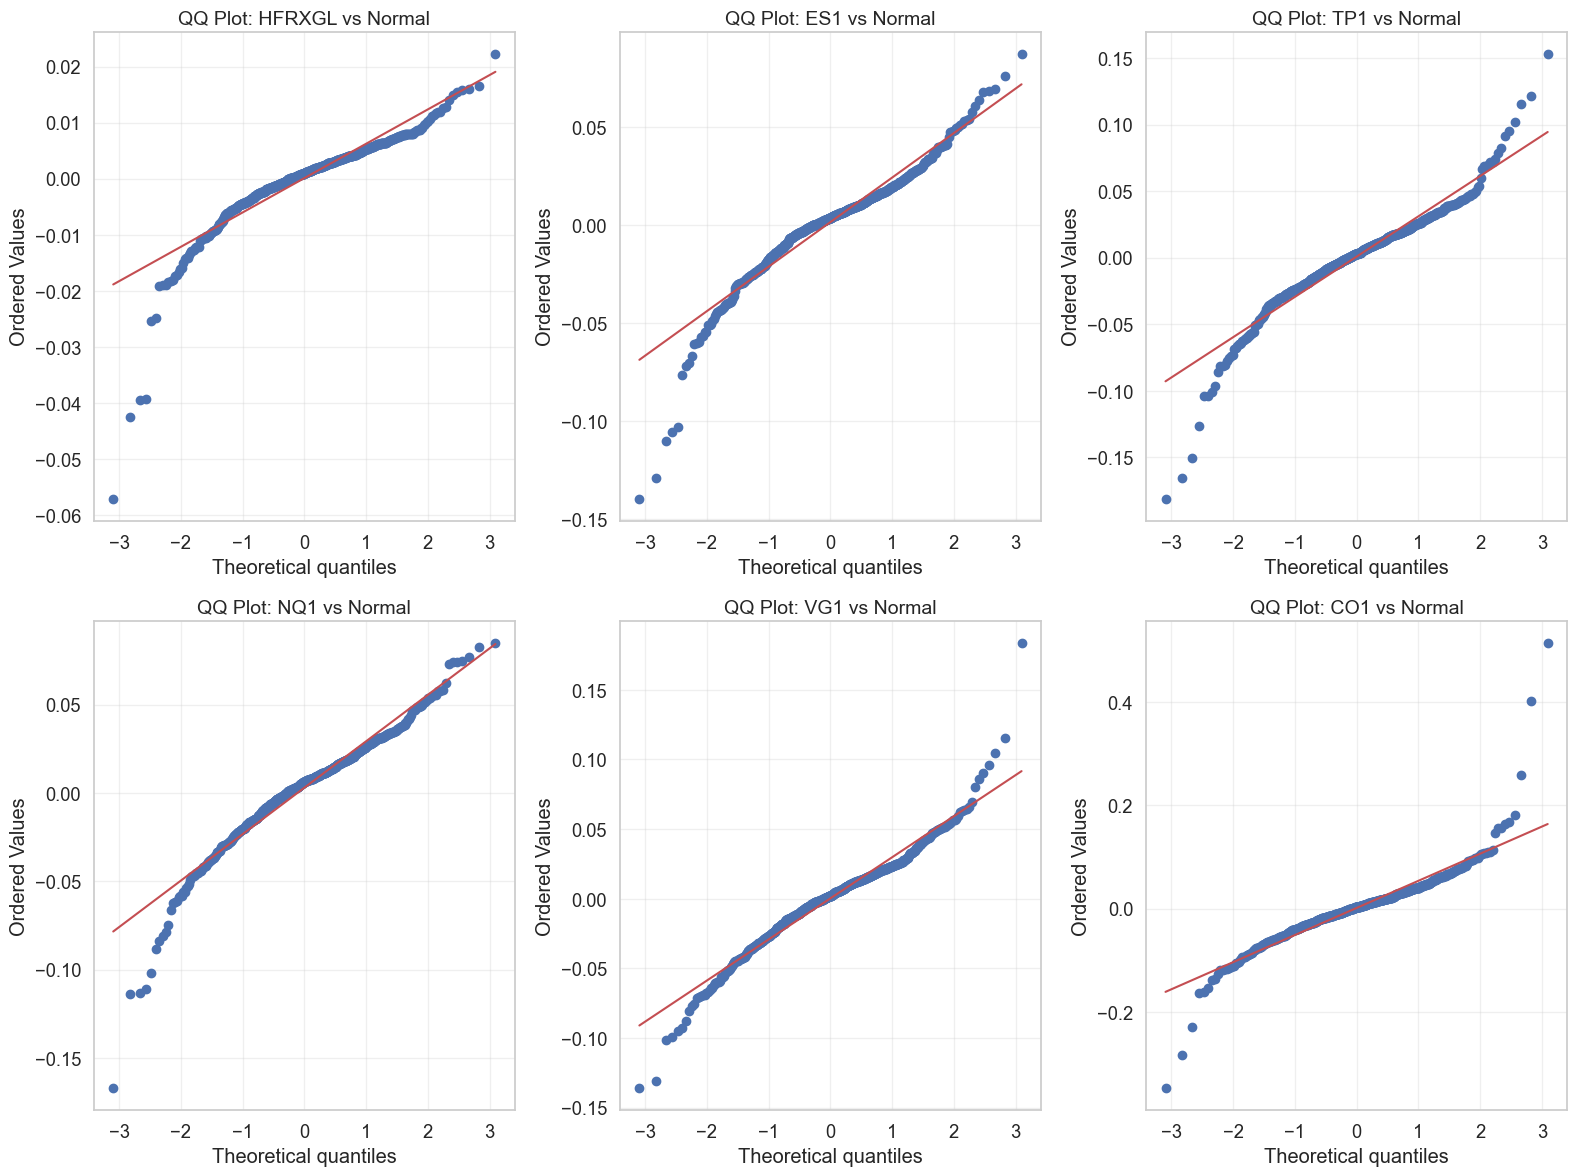

In [23]:
# ── 5. Target vs Predictors: Correlation & Normality ──────────────────────

# 1. Slice our existing Master returns dataframe
target_series = all_returns[MAIN_TARGET]
futures_series = all_returns[FUTURES]

# 2. Calculate Correlations
correlations = futures_series.corrwith(target_series).to_frame('Correlation_with_Target')

# Sort by absolute correlation to find the strongest drivers
correlations['Abs_Corr'] = correlations['Correlation_with_Target'].abs()
correlations = correlations.sort_values('Abs_Corr', ascending=False)

print(f"=== Top Futures Correlated with {MAIN_TARGET} ===")
display(correlations[['Correlation_with_Target']].head(5))

# 3. Create QQ plots using our extended 2x3 layout function
# This identifies if the "Fat Tails" we found in the target exist in the features too
print("\n=== Normality Check (QQ Plots) ===")
top_5_futures = correlations.index[:5].tolist()
plot_qq_normality_extended(target_series, futures_series, top_5_futures)

In [24]:
# Print the top correlated futures, just for reference
print("Top futures contracts by correlation with target index:")
display(correlations.head())

Top futures contracts by correlation with target index:


,Correlation_with_Target,Abs_Corr
ES1,0.441119,0.441119
TP1,0.394622,0.394622
NQ1,0.390603,0.390603
VG1,0.341651,0.341651
CO1,0.277859,0.277859


<br>

We'll analyze the **autocorrelation** properties of our target indices to understand their time series behavior. It is possible to take this into account in modelling, and in any case it is better to know what the situation is.

<br>

=== ACF & PACF Analysis (20 Lags) ===


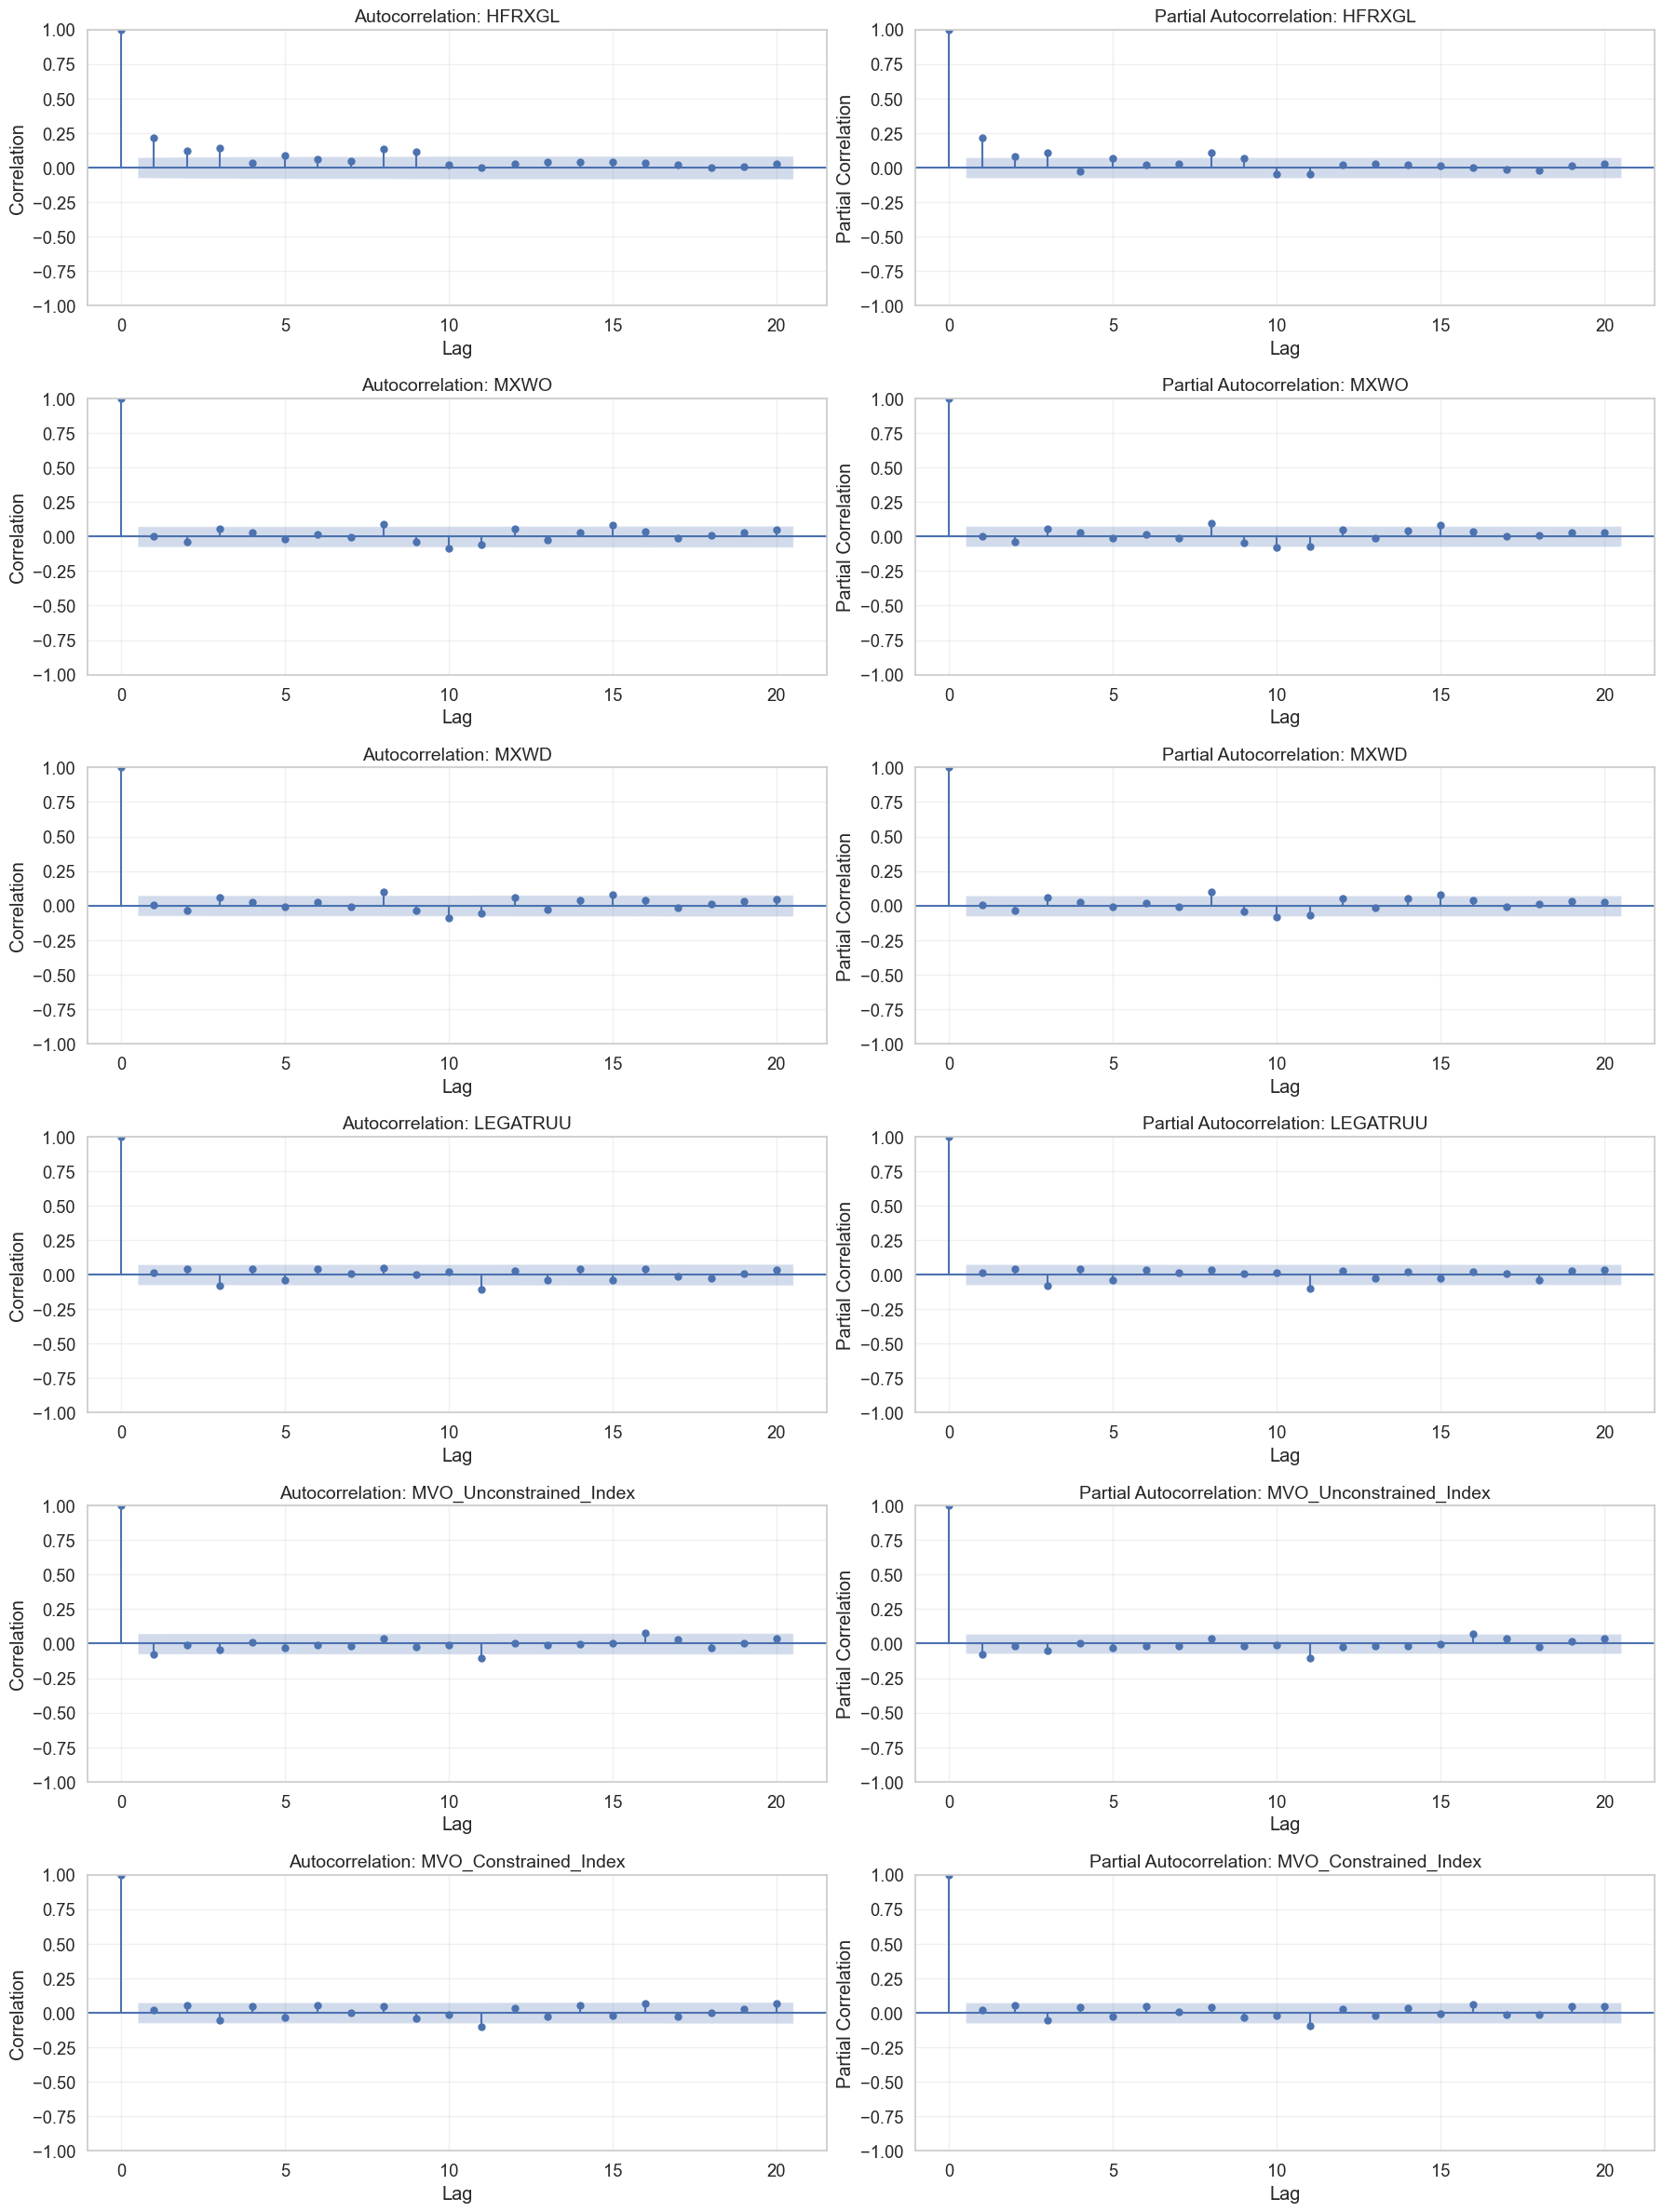

In [25]:
# ── 6. Autocorrelation Analysis ───────────────────────────────────────────
# We check for serial correlation (momentum/mean-reversion) to ensure
# independent observations

max_lags = 20
print(f"=== ACF & PACF Analysis ({max_lags} Lags) ===")
plot_acf_pacf(all_returns, TARGETS, max_lags=max_lags)

Some **statistical tests for Autocorrelation**:
Let's perform formal statistical tests to check for autocorrelation in our return series.

In [26]:
# ── 7. Quantitative Autocorrelation Test (Ljung-Box) ──────────────────────
from statsmodels.stats.diagnostic import acorr_ljungbox

print("=== Ljung-Box Test p-values (H0: No Autocorrelation) ===")
print("Note: Values < 0.05 (in red) indicate significant autocorrelation (reject H0).\n")

lags_to_test = [5, 10, 15, 20]
lb_results = {}

# Run the test for each target in our clean universe
for col in TARGETS:
    if col in all_returns.columns:
        # return_df=True ensures consistent DataFrame output across statsmodels versions
        lb_test = acorr_ljungbox(all_returns[col], lags=lags_to_test, return_df=True)

        # Extract just the p-values mapped to their lag
        lb_results[col] = {f"Lag {lag}": lb_test.loc[lag, 'lb_pvalue'] for lag in lags_to_test}

# Convert dictionary to a clean DataFrame (Rows = Targets, Columns = Lags)
lb_df = pd.DataFrame(lb_results).T

try:
    styled_df = lb_df.style.format("{:.4f}").map(highlight_significant)
except AttributeError:
    styled_df = lb_df.style.format("{:.4f}").applymap(highlight_significant)

display(styled_df)

=== Ljung-Box Test p-values (H0: No Autocorrelation) ===
Note: Values < 0.05 (in red) indicate significant autocorrelation (reject H0).



,Lag 5,Lag 10,Lag 15,Lag 20
HFRXGL,0.0000,0.0000,0.0000,0.0000
MXWO,0.5905,0.0910,0.0258,0.0521
MXWD,0.5393,0.0653,0.0188,0.0432
LEGATRUU,0.1364,0.3071,0.0681,0.1484
MVO_Unconstrained_Index,0.2257,0.5553,0.3540,0.2852
MVO_Constrained_Index,0.2775,0.3510,0.1081,0.0774


<br>

**Volatility Clustering Analysis**: Financial returns often exhibit volatility clustering - periods of high volatility tend to be followed by similar high volatility periods. We'll examine this phenomenon: as before, it is possible to take this into account in the modelling, and in any case it is better to know what the situation is.

<br>

=== Volatility Clustering Analysis (20 Lags) ===


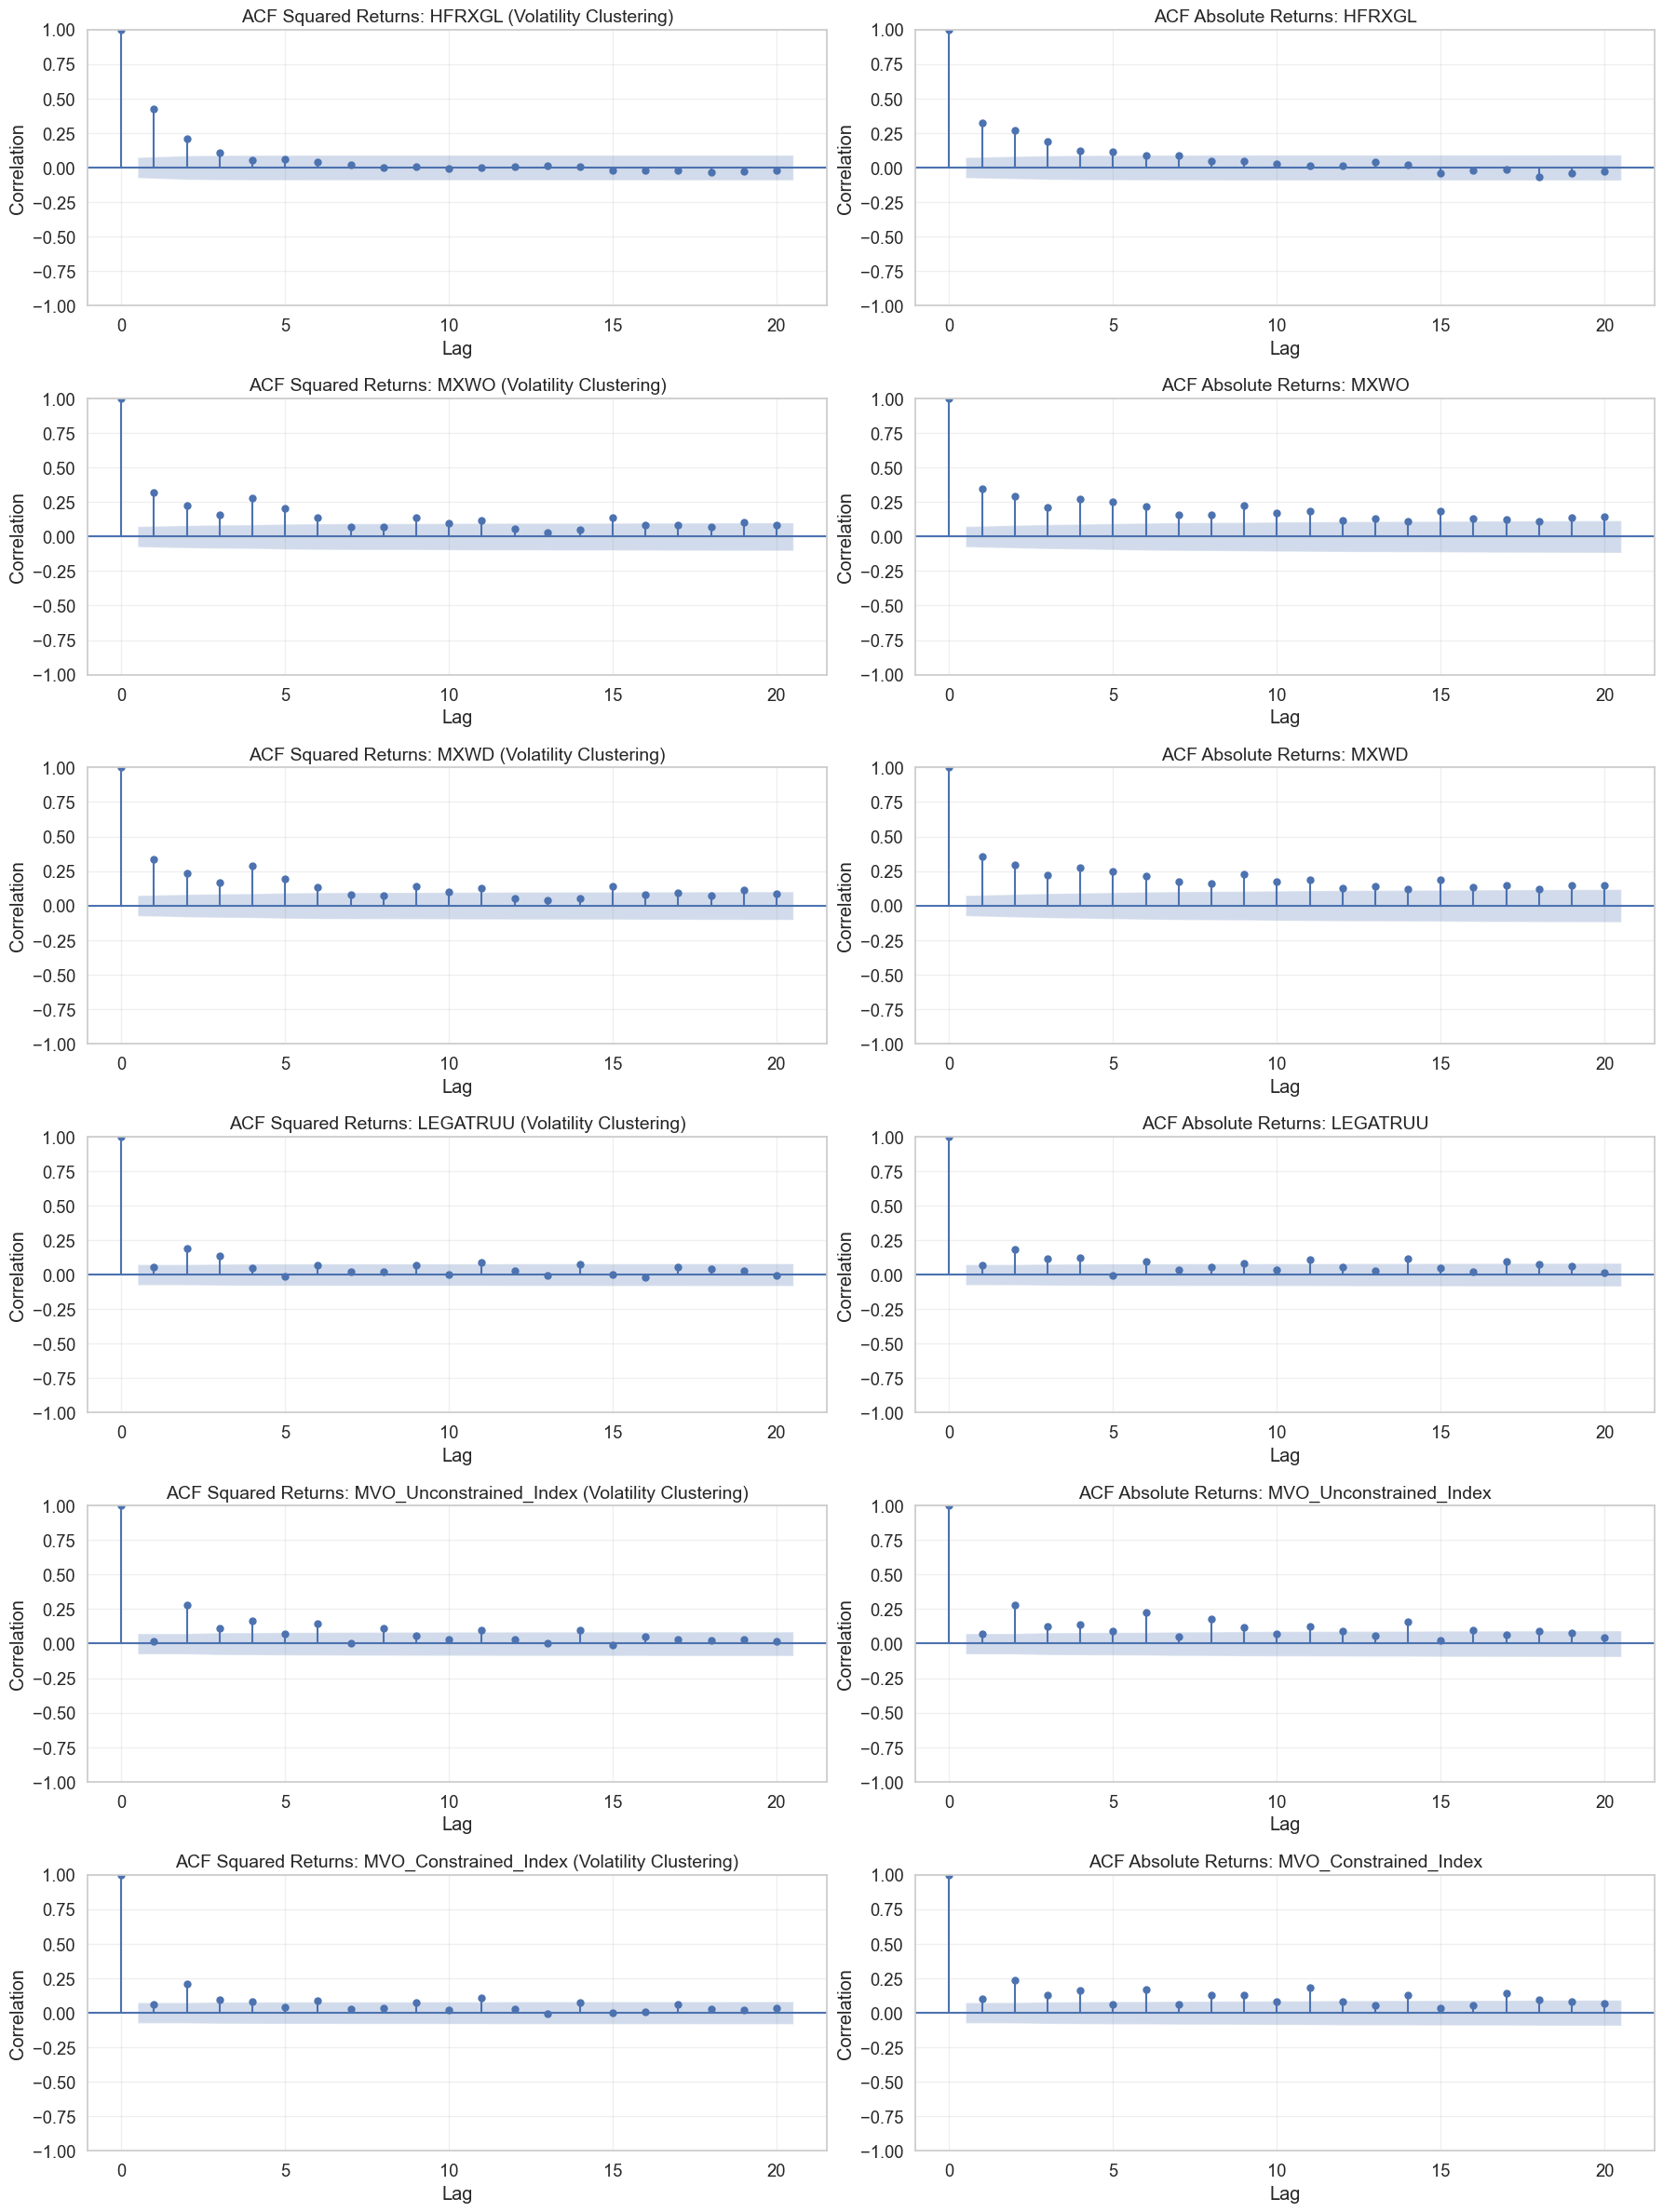

In [27]:
# ── 8. Volatility Clustering Analysis ─────────────────────────────────────
# We check the autocorrelation of squared and absolute returns.
# Significant spikes here indicate volatility clustering (ARCH/GARCH effects),
# meaning high-volatility weeks tend to follow high-volatility weeks.

max_lags = 20
print(f"=== Volatility Clustering Analysis ({max_lags} Lags) ===")

# Pass the full TARGETS list to see how different asset classes behave
plot_volatility_clustering(all_returns, TARGETS, max_lags=max_lags)

<br>

Now let's analyze our constructed target index, the Monster Index, and Futures contracts that are candidates to replicate it in more detail to understand its characteristics before attempting replication.

<br>

=== Rolling Correlation (52-Week Window) ===


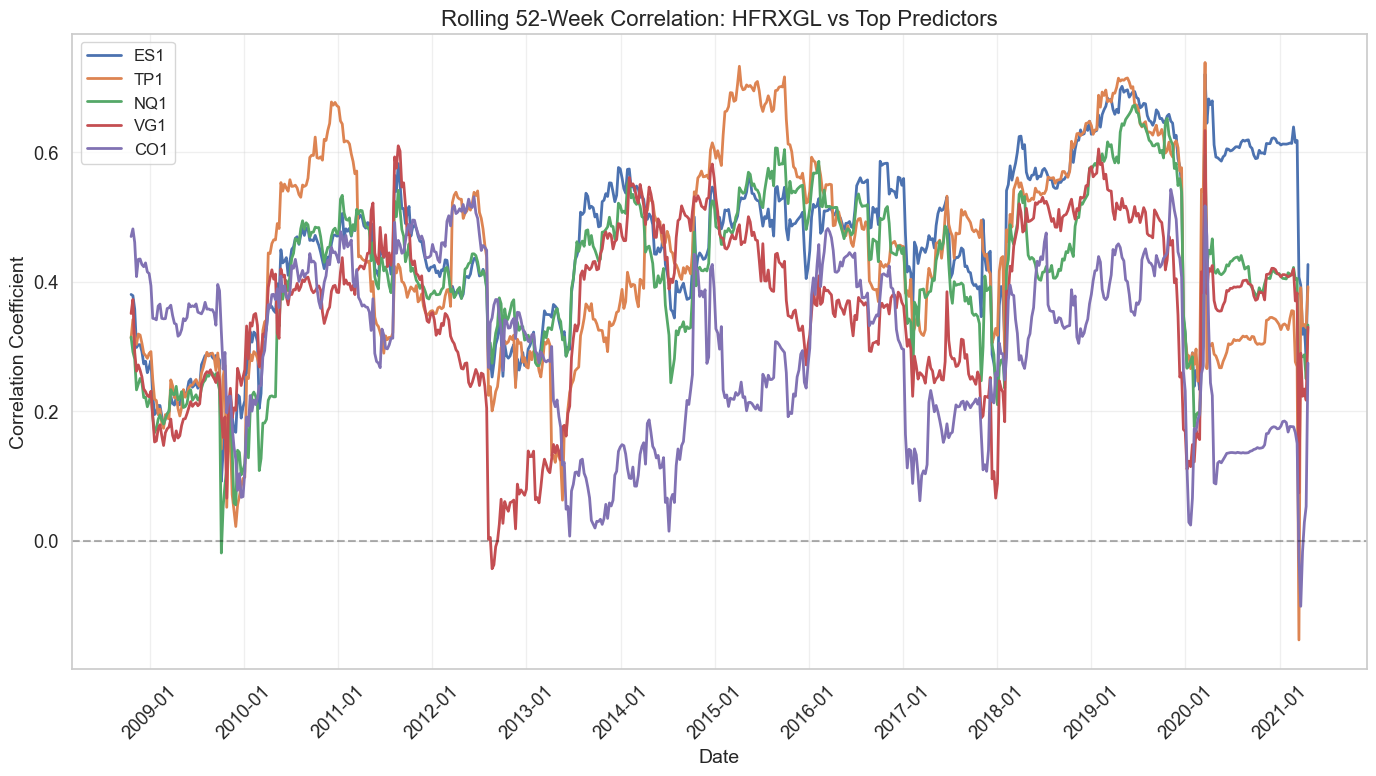

In [28]:
# ── 9. Rolling Correlation Analysis (Parameter Stability) ─────────────────
# We check if the correlations between our target and predictors are stable
# over time. Highly volatile correlations can break static regression models.

rolling_window = 52  # 52 weeks ≈ 1 year
print(f"=== Rolling Correlation ({rolling_window}-Week Window) ===")

# Pass our combined returns dataframe, the target, and the top 5 list
plot_rolling_correlations(all_returns, MAIN_TARGET, top_5_futures, window=rolling_window)

If you look at the time series and their correlations with the target, they have heterogeneous paths, so it's intuitive that they can be of help, if we want to replicate complex assets, such as our "Monster Index".

In [29]:
# ── 10. Multi-Target Performance Comparison ────────────────────────────────
# We compare the statistical signatures of our targets.
# Weekly vs. Monthly views reveal the "Smoothing Effect" found in EDA.

# 1. Select the targets we want to compare (usually HFRXGL and Monster)
comparison_targets = [MAIN_TARGET, 'MVO_Unconstrained_Index']
all_stats = []

for t in comparison_targets:
    t_returns = all_returns[t]

    # Weekly view
    wk_stats = get_comprehensive_stats(t_returns, freq='W')
    wk_stats.name = (t, 'Weekly')

    # Monthly view
    mo_returns = t_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
    mo_stats = get_comprehensive_stats(mo_returns, freq='M')
    mo_stats.name = (t, 'Monthly')

    all_stats.extend([wk_stats, mo_stats])

# 2. Create Multi-Index DataFrame
stats_df = pd.concat(all_stats, axis=1)
stats_df.columns = pd.MultiIndex.from_tuples(stats_df.columns)

# Custom formatting application
formatted_stats = stats_df.apply(lambda row:
    row.map(lambda x: f"{x*100:.2f}%") if row.name in ['Annualized Return', 'Annualized Volatility', 'Max Drawdown']
    else row.map(lambda x: f"{x:.2f}"), axis=1)

print("=== Final Target Baseline Comparison ===")
display(formatted_stats)

=== Final Target Baseline Comparison ===


HFRXGL          MVO_Unconstrained_Index        
                        Weekly  Monthly                  Weekly Monthly
Annualized Return        0.50%    0.57%                   5.03%   4.98%
Annualized Volatility    4.78%    6.09%                   6.29%   5.69%
Sharpe Ratio              0.10     0.09                    0.80    0.88
Max Drawdown           -24.91%  -24.70%                 -11.59%  -8.84%
Skewness                 -2.30    -2.50                   -0.36   -0.16
Kurtosis                 13.70    10.81                    3.89    1.30

=== Scatter Plot Matrix: HFRXGL vs Top 5 Futures ===


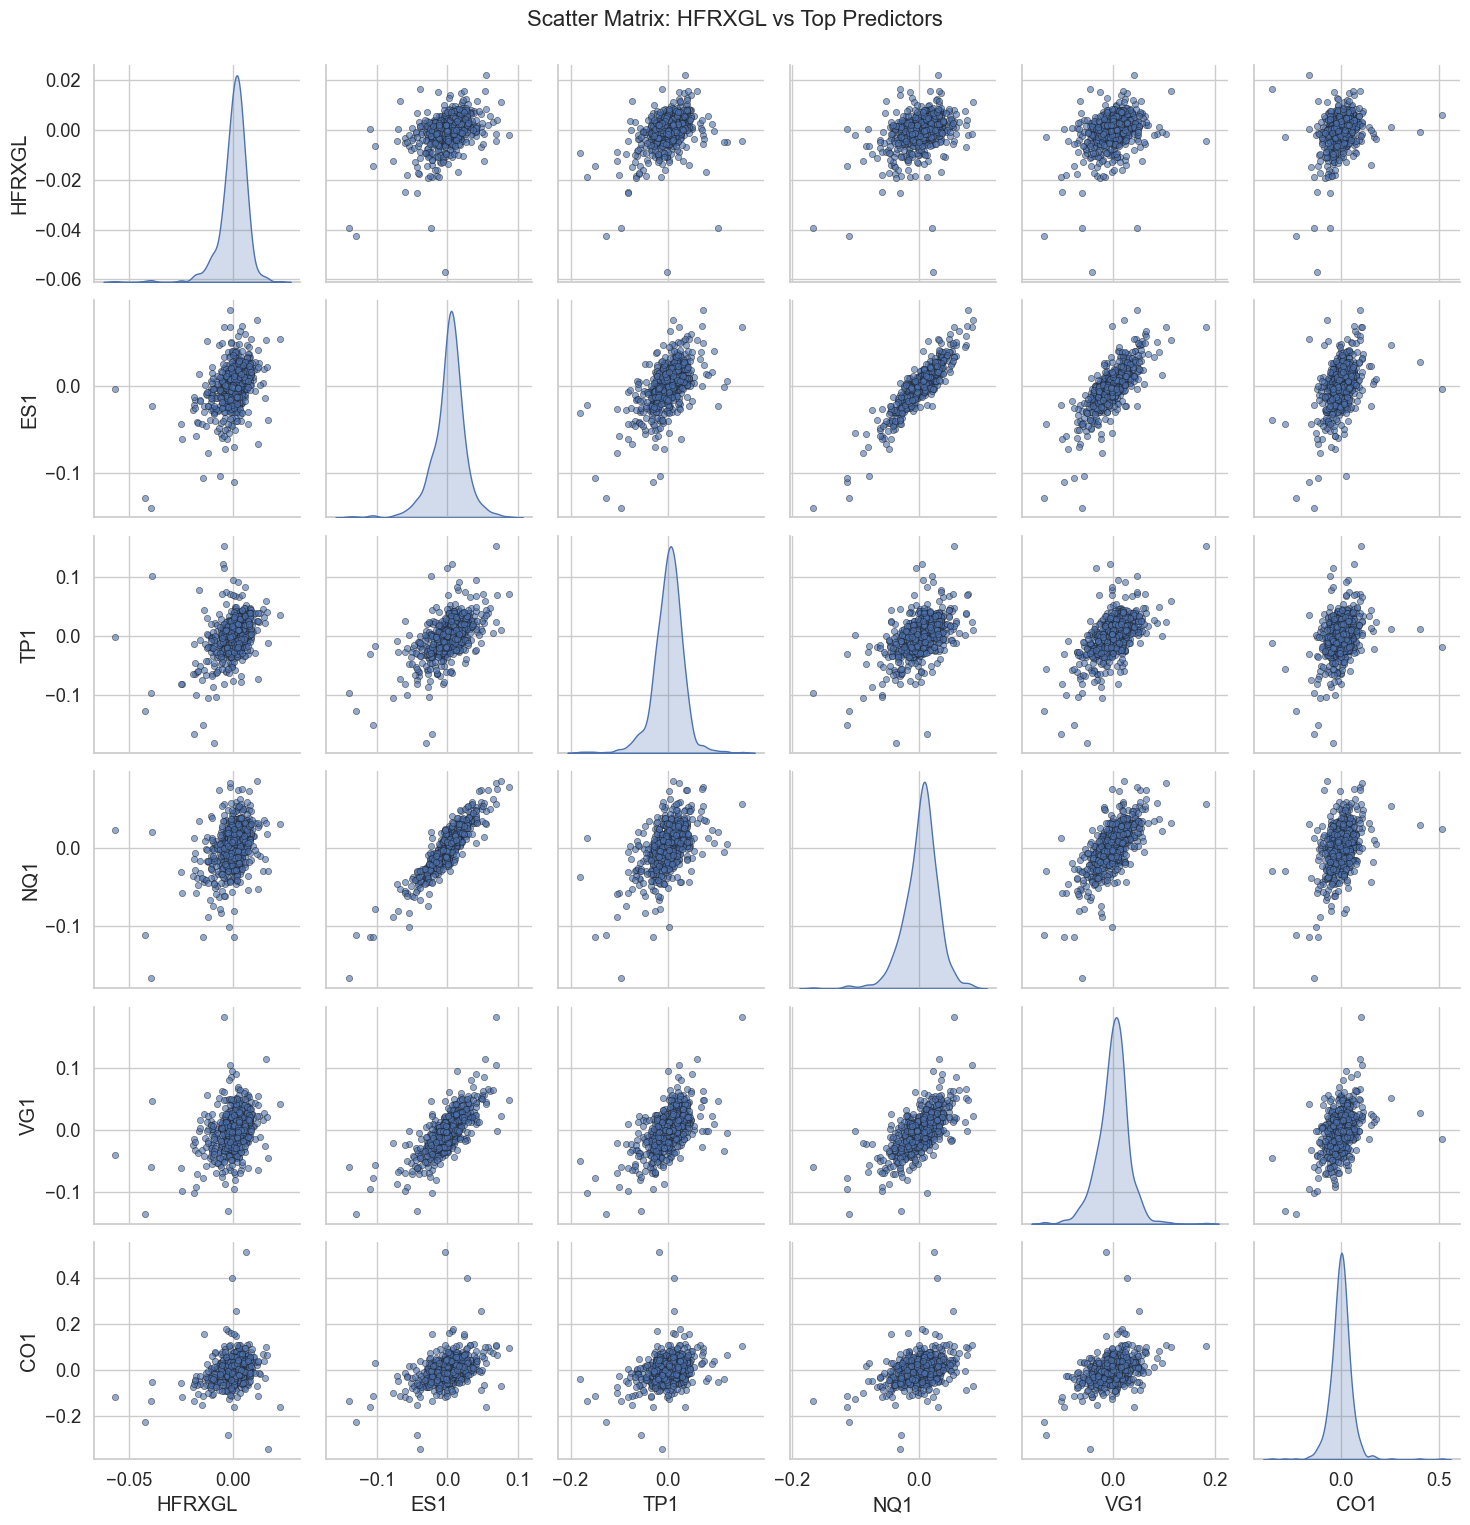

In [30]:
# ── 11. Scatter Plot Matrix (Linearity Check) ─────────────────────────────
# We visually inspect the relationships between our target and top predictors
# to ensure they are roughly linear (a core assumption of Lasso regression)
# and to spot any severe outliers.

print(f"=== Scatter Plot Matrix: {MAIN_TARGET} vs Top 5 Futures ===")

# Generate the plot using our active dataset
plot_scatter_matrix(all_returns, MAIN_TARGET, top_5_futures)

---
## 4. Fama-French 3-Factor Analysis

### Fama-French 3-Factor Decomposition
This analysis regresses the target's excess returns against the **Market**, **Size (SMB)**,
and **Value (HML)** factors.
* **Alpha**: Indicates "Skill" or returns not explained by these broad risk factors.
* **Beta**: Indicates the sensitivity to an arbitrary index adapted to the security with respect to which you measure the volatility to.
* **SMB**: Indicates if the returns are a consequence of small caps (higher risk induces higher return).
* **HML**: Indicates if the strategy takes into account the Book-to-Market factor (if an asset is undervalued on the market).
* **R-Squared**: Shows how much of the target's behavior is simply "disguised" equity beta.

In [ ]:
# 4. Fama-French 3-Factor Analysis 

# We regress the target excess returns against the Fama-French factors
# (Market Risk Premium, Size, Value) to determine if the target generates
# true Alpha, or if its returns are just disguised equity beta.

try:
    # 1. Fetch Fama-French data using the helper function (ONLY ONCE)
    ff_data = get_fama_french_data()
    
    def highlight_pvals(val):
        color = '#d62728' if val < 0.05 else 'inherit'
        return f'color: {color}; font-weight: {"bold" if val < 0.05 else "normal"}'

    # Iterate over all targets
    for target in TARGETS:
        print()
        print(f"=== Fama-French 3-Factor Decomposition for: {target} ===")
        
        # 2. Prepare our local target data
        target_returns = all_returns[target]
        monthly_target = target_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
        monthly_target.name = target
        monthly_target.index = monthly_target.index.to_period('M')

        # 3. Align and Merge
        common_dates = monthly_target.index.intersection(ff_data.index)
        if len(common_dates) == 0:
            print(f"Error: No common dates found for {target}.")
            continue

        ff_merged = pd.concat([monthly_target.loc[common_dates], ff_data.loc[common_dates]], axis=1)

        # 4. OLS Regression Setup
        # Target (y): excess return (Target - Risk-Free Rate)
        y = ff_merged[target] - ff_merged['RF']

        # Predictors (X): Fama-French Factors + Constant for Alpha
        X = ff_merged[['Mkt-RF', 'SMB', 'HML']]
        X = sm.add_constant(X)

        ff_model = sm.OLS(y, X).fit()

        # 5. Display Results
        results_df = pd.DataFrame({
            'Coefficient': ff_model.params,
            'Std Error': ff_model.bse,
            't-Stat': ff_model.tvalues,
            'P-Value': ff_model.pvalues
        })

        print("Regression Coefficients:")
        results_df.rename(index={'const': 'Alpha (Skill)'}, inplace=True)
        display(results_df.style.format('{:.4f}').map(highlight_pvals, subset=['P-Value']))

        rsquared_df = pd.DataFrame({
            'Metric': ['R-squared', 'Adjusted R-squared'],
            'Value': [ff_model.rsquared, ff_model.rsquared_adj]
        })
        display(rsquared_df.style.format({'Value': '{:.4f}'}))
        
except Exception as e:
    print("Error during Fama-French analysis:")
    print(traceback.format_exc())



=== Fama-French 3-Factor Decomposition for: HFRXGL ===
Regression Coefficients:


,Coefficient,Std Error,t-Stat,P-Value
Alpha (Skill),-0.0025,0.0011,-2.3589,0.0195
Mkt-RF,0.2576,0.0240,10.7151,0.0000
SMB,0.0235,0.0453,0.5187,0.6047
HML,-0.0415,0.0357,-1.1623,0.2469


,Metric,Value
0,R-squared,0.4626
1,Adjusted R-squared,0.4524



=== Fama-French 3-Factor Decomposition for: MXWO ===
Regression Coefficients:


,Coefficient,Std Error,t-Stat,P-Value
Alpha (Skill),-0.0042,0.0019,-2.2034,0.0290
Mkt-RF,0.9762,0.0430,22.6888,0.0000
SMB,-0.1530,0.0810,-1.8885,0.0608
HML,-0.0204,0.0639,-0.3197,0.7496


...

,Coefficient,Std Error,t-Stat,P-Value
Alpha (Skill),0.0023,0.0012,1.8963,0.0597
Mkt-RF,0.1654,0.0274,6.0435,0.0000
SMB,-0.1307,0.0515,-2.5369,0.0121
HML,-0.0296,0.0406,-0.7291,0.4670


,Metric,Value
0,R-squared,0.1904
1,Adjusted R-squared,0.1751



=== Fama-French 3-Factor Decomposition for: MVO_Constrained_Index ===
Regression Coefficients:


,Coefficient,Std Error,t-Stat,P-Value
Alpha (Skill),0.0008,0.0012,0.6588,0.5110
Mkt-RF,0.1921,0.0270,7.1206,0.0000
SMB,-0.1063,0.0508,-2.0926,0.0380
HML,-0.0642,0.0401,-1.6023,0.1111


,Metric,Value
0,R-squared,0.2419
1,Adjusted R-squared,0.2276


### Fama-French 3-Factor Analysis: Key Takeaways

**1. Hedge Funds (HFRXGL)**
*   **Market Risk:** Low (`Mkt-RF` = 0.26, `R²` = 46%). Confirms the index provides true diversification from standard equities.
*   **Alpha (Skill):** **Negative & Significant** (-0.0025, `p=0.019`). After adjusting for market risk, average hedge funds destroyed value (likely due to high fees and underperformance).

**2. Global Equities (MXWO & MXWD)**
*   **Market Risk:** Pure market exposure (`Mkt-RF` ~ 0.98, `R²` ~ 78%). 
*   **Alpha & Factors:** Zero alpha and no significant tilts to Size or Value. They act exactly as expected: broad, passive equity proxies.

**3. Global Bonds (LEGATRUU)**
*   **Model Fit:** Extremely poor (`R²` = 8.5%). 
*   **Conclusion:** The Fama-French model fails here because it only measures equity risk premiums, completely missing interest rate and credit risks.

**5. Unconstrained Markowitz**
*   **Beta Cancellation:** Despite massive leverage (+259% Long MXWO, -246% Short MXWD), the net equity risk is neutralized (`Mkt-RF` = 0.16).
*   **Factor Arbitrage:** It heavily shorts Emerging Markets while longing Developed Markets, creating a strong Large-Cap arbitrage (Negative `SMB`, `p=0.012`).
*   **Alpha (Skill):** **Positive** (`p=0.059`). The optimizer successfully squeezed out theoretical alpha through statistical arbitrage, though this remains practically untradable due to real-world borrowing costs.

**4. Constrained Markowitz**
*   **Profile:** Acts like a bond fund due to its ~90% fixed-income allocation. Low market beta (0.19) and low `R²` (24%).
*   **Factor Tilt:** Shows a significant "Large-Cap" bias (Negative `SMB`, `p=0.038`) inherited from its 10% allocation to MXWO. Alpha is zero.


---
## 5. Summary

In [16]:
# Save the cleaned data so the Modelling notebook can use it
all_returns.to_pickle("all_returns_data.pkl")